# Week 19 - Predictive Maintenance
Predictive Maintenance planning is an extremely complex area, utilising many data sources, and relying on several highly-stochastic factors including weather, turbine behaviour and supply. Additionally, this area handles decisions which can significantly decrease operation and maintenance costs. Whilst this area will always rely heavily on human expertise, machine learning can help improve and automate some predictive and optimisation based areas. Firstly, they can help us to detect when a fault or issue has begun to occur or worsen. Secondly, they can be used to forecast outcomes and predict future behaviour of a system. Finally, they may be able to help us to select a strategy amongst a set using optimisation.


## 1 Detection

### 1.1 Classification
Classification models are a type of **supervised learning**, which you may recall is a subset of Machine Learning taking in labelled data. This means we will have some input data, such as SCADA, temperature data, vibration signals, or a combination of these, which have corresponding labels telling us whether the devices are healthy or experiencing a fault. These categories can be more complex than this binary situation such as 'low', 'medium' or 'high' risk of failure, or amount of useful time remaining such as more than 1 year, 6 months - 1 year, 3-6 months, or less than 3 months. Once the model has been trained, it can then be used to take in new input data and determine the category. This can enable us to understand which devices or components in a fleet are experiencing a fault or at risk of failure, and prioritise maintenance actions.

Several models can be used for this purpose, some of these we have already covered in our learning.

#### Neural Networks
As this course has just covered Neural Networks I won't discuss the methodologies, but FNN, CNN and LSTM models can all be used to train classifiers for this purpose.

#### Tree-based Models
A decision tree works by first starting with a **root** question. In this case the question might be "*Is this component healthy or faulty?*". The tree then works like a flow chart, we ask sequential yes/no questions about the data, such as "*Is the temperature higher than 20 degrees?*". These questions, or split points, are known as **internal nodes**. Each question will split the data further until we have several subsets of data in defined groups which have reached different end points of the tree. These end points are referred to as **leaves**.The training process determines which questions optimally separate data, and which category the data in each end group usually falls into (some tree-based methods separate data during training in such a way that all data points within an end group must be in the same category). New input data then is separated through the nodes and its label is determined by its end group.

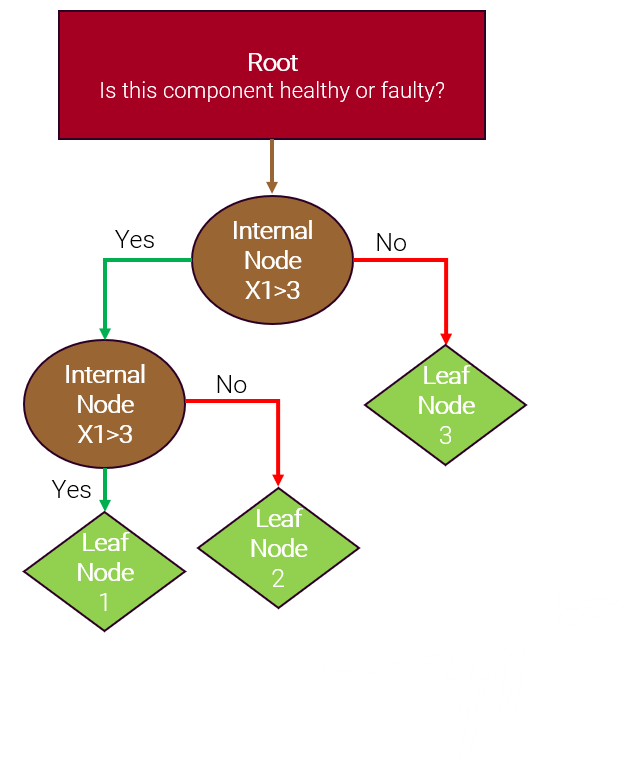

Each group (leaf node) gets a prediction score based on trained outputs.
In decision trees, splitting criteria help decide which feature to split on at each node. The two most common are:
Gini Index:
$$I_g=1-\sum_{j=1}^{c}p_j^2,$$
where p_j is the proportion of the samples that belong to class $c$ for a particular node
Entropy:
$$I_H= -\sum_{j=1}{c}p_j log_2(p_j),$$ 
entropy is 0 if all samples at a node belong to the same class.

Ensemble methods work by training multiple trees and combining their decision making. Think of these as a group of experts discussing their opinion and coming to a shared decision. The most commonly used ensemble method is XGBoost. XGBoost works by building sequential decision trees each trying to correct the errors of the previous tree. Another common ensemble method is Random Forests, this works by training several decision trees in parallel and taking the majority vote amongst these trees to make decisions. This helps reduce overfitting of the model.
Both of these models improve upon a single decision tree in terms of performance and overfitting. XGBoost should be used when performance is the most important objective, as well as for large data sets and those with sparse or missing values. This model can also be well optimised for speed when sufficient computational power is available. For limited computational power, high-dimensional data, high risk of overfitting, or when a model should be easy to interpret, Random Forests are more appropriate.

This table from [GeekforGeeks](https://www.geeksforgeeks.org/machine-learning/difference-between-random-forest-vs-xgboost/) summarises well when to use which method.
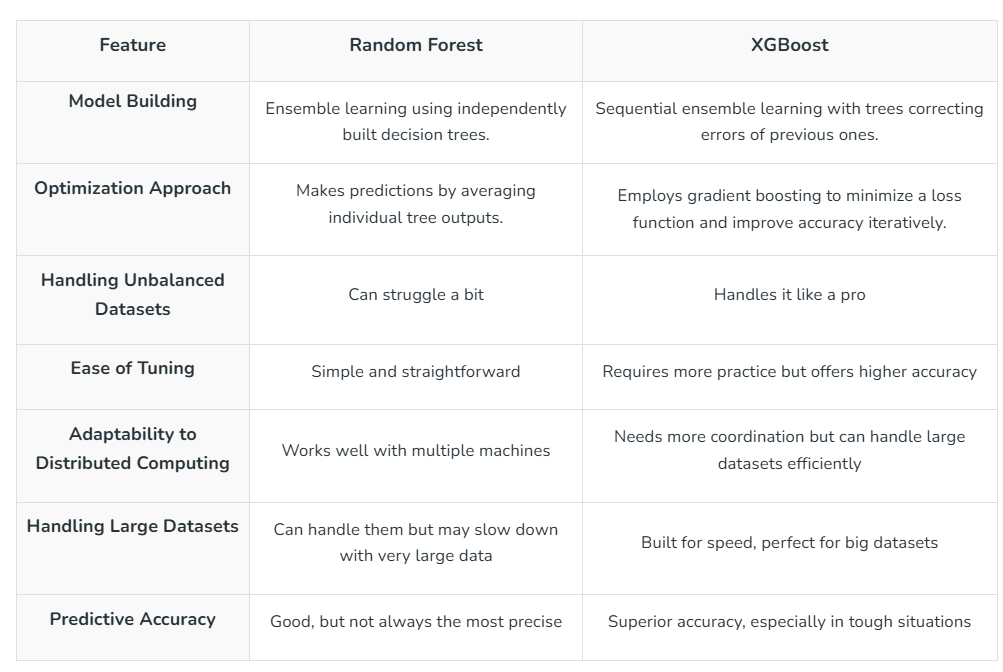
#### Support Vector Machine (SVM)
Support Vector Machine models work by defining a surface which separates groups. In the two-dimensional case this involves defining a line, such as in the image below from [GeekforGeeks](https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/)


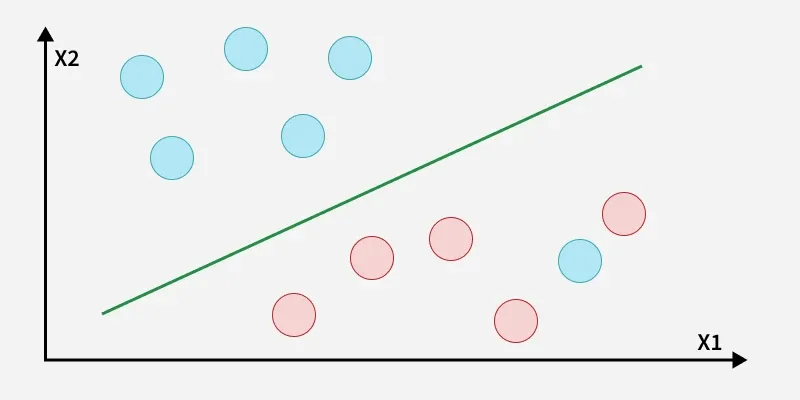.

The model aims to maximise the distance between the boundary and the closest data points on each side. 

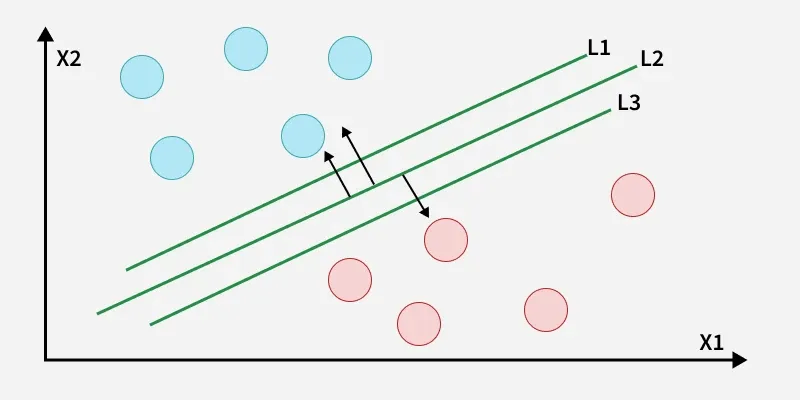

This method of training makes the model highly robust to outliers far from the core of the group away from the margin, and uses a soft-margin to reduce influence of overlapping outlier points.

This model extends to higher dimension by defining a surface instead of a straight line, and may be used for either binary or multi-class classification. Where data cannot be split using a single straight boundary, SVM uses kernels to translate the data into a high-dimensional space where it may become separable. However, for extremely noisy data and overlapping points, this method becomes innappopriate.

SVM is highly efficient once trained, but can be slow to train both with regards to computation and the person-time required for hyperparameter tuning.

#### K-Nearest Neighbour (KNN)
K-Nearest Neighbour is a simple, nonparametric method which views the labels of the $n$ closest training data points to the data point of interest, and assigns the point of interest to the majority class of these neighbouring points. The number of neighbours considered, $n$, is determined prior to model training. For example, if the closest data points are Class 1, Class 2, Class 1 and Class 3 respectively, the new data point would be assigned to Class 1.

### 1.2 Anomaly Detection 
Within wind energy faults and failures are relatively uncommon and make up a minority of data available. As such, training a classification method is not always feasible as there may be insufficient data for fault cases. Although some of this can be tackled using minority-class handling methods described in Section 6, another method is to use **Anomaly Detection** to learn normal behaviour and identify when we deviate from this.

#### Frequency-based
One of the simplest anomaly detection methods involves defining a histogram of normal behaviour. If new points would not be contained within any histogram bins, these points are then considered anomalous.

#### Statistical Scores
Statistical methods can be used to fit a distribution to the data and use statistical scores to determine whether this data point is part of normal distributional behaviour using a similar process to hypothesis testing.

#### Ensemble Methods
Ensemble methods including both random forests and XGBoost can be used to train to normal behaviour and identify outliers.


#### Neural Networks
Neural Networks including autoencoders, LSTMs, CNNs and Bayesian Networks have all shown high suitability for anomaly detection.

#### Density-based
Density-based methods such as DBScan and Isolation Forests identify where new points fall far from the normal set of data points by identifying layered changes in density of training data.

#### Clustering
Clustering, or unsupervised grouping, can be used to identify a core 'normal' group as well as outlier groups. These methods may also offer the ability to separate levels of severity amongst anomalous points.

## 2 Forecasting
Forecasting methods allow us to predict future behaviour to understand how quickly a fault might progress, or whether current behaviour may later develop into a fault.

#### Time-series based
Time-series methods would like at the time history of variables such as temperature, and predict future time steps. This would allow us to predict how rapidly this parameter (or combination of parameters) would escalate. One use of this is that we may have some threshold value where when a certain temperature, for example, is exceeded we would intervene. Forecasting could therefore enable us to predict the required intervention time. Auto-Regressive Moving Average is one of the most common methods amongst these, along with adjusted versions Auto-Regressive Integrated Moving Average (ARIMA) and Seasonal Auto-Regressive Moving Average (SARIMA). Neural Networks which work well to incorporate time history such as LSTM are also very appropriate for this task. These methods will be covered in depth in the next session.

#### Monte-Carlo Simulations
Monte-Carlo Simulations are a stochastic forecasting method which uses probability of certain changes or events to predict the outcome. This method can be used to predict the probability of a failure occurring, or to predict the time taken to reach a failure state. Monte-Carlo simulations can also be combined to understand supply chain issues, time until weather is safe to carry out repair, cost etc. to provide a holistic model for varies maintenance strategies.

## 3 Optimisation
Machine Learning methods as well as core statistical and mathematical approaches may be used to compare a number of different maintenance strategies and determine an optimal approach. These models can take into account weather forecasting, supply chain forecasting, predictive failure behaviour and weigh cost of preventative vs reactive actions. 

#### Constraint-based
Simple optimisation approaches will take in certain information such as the cost of various repairs and potential outcomes following these repairs each with an associated probability, alongside a set of constraints e.g. no repairs can be done if there is rain, repairs take 3 days etc. which will all be converted into linear equations e.g. precipitation on repair day 1, 2 and 3 = 0. Algorithms can then be used to find an ideal solution through trying to minimise cost (cost may include the lost earnings from shutdown time) whilst adhering to the constraints.

#### AI-based
Both traditional Machine Learning and agentic AI based methods can assist in determining the most suitable approach amongst a set. This can be trained on previous expert decisions, or based on information provided about risk factors and potential outcomes of each option.

#### Risk factor based
Cost and risk can be modelled using a variety of Machine Learning approaches, linked to each method and provided to an expert who can then decide best approach based on the modelled predictions of each scenario outcome.

## 4 Digital Twins
Digital twins are often referred to in industry to refer to a single one of the methods described above such as a Monte-Carlo simulation or a forecasting approach, but generally it should be used to refer to a digital model of a farm, asset, or component capable of simulating or predicting behaviour. Ideally, this digital model is updated frequently with live measurements and can react to changes in the real world to estimate how the system may respond. These models are very complex and are often a combination of surrogate models trained on aeroelastic simulations, physics-based models, and machine learning or data driven models. 

## 5  Survival Analysis
The methods described in the Survival Analysis module earlier in the course are highly applicable to predictive maintenance. Although many are simple and non-parametric they can be used for long term budgeting and estimates, and may be combined with more complex machine learning approaches to provide highly accurate output.

## 6 Handling Minority Data
As fault behaviour makes up the minority of turbine data, we often need to do some additional work to ensure models do not overfit to the 'normal behaviour case'. This can be done by either oversampling (duplicating data points falling into this class), undersampling (removing some normal behaviour points from the dataset), or by generating synthetic failure data to supplement the true cases. Additionally, we can alter the optimisation or fitting process by assigning higher priority or a higher loss to those falsely assigned to the normal behaviour class.
Additionally, as with survival analysis, we can use methods designed to incorporate censoring. We can consider the failure time of normal behaviour devices to be some unknown time in the future and incorporate the data as 'right-censored'.